In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=LlmyWFHl42Et4FScVNoqHTSUlCMXPv&access_type=offline&code_challenge=NjoDPuQQUcbR50JTc9QEKtPFUIdf4dk61OMtQ3isEQc&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


Updates are available for some Google Clo

In [2]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/13 22:26:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder="gs://open-targets-data-releases/25.06/"


si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

sl_eff=session.spark.read.parquet("gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect")

l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet")

In [4]:
si_df=si.df.filter(f.col("studyType")=="gwas").toPandas()
si_df.to_csv("study_index_gwas.tsv",sep="\t",index=False)

25/11/13 22:27:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [3]:
l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet")

In [4]:
qd_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets").select("studyLocusId").cache()
qd_cs.count()
qm_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_measurement_credible_sets").select("studyLocusId").cache()
qm_cs.count()
qcs=qd_cs.union(qm_cs).distinct().cache()
qcs.count()

520975

In [5]:
l2g_full=l2g_full.join(qcs,on="studyLocusId",how="inner").cache()
l2g_full.count()

523409

In [6]:
l2g_full.show(2)

+--------------------+------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+
|        studyLocusId|     studyId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                maf|       variantId|year|is_nfe|   diseaseIds|nfe_common|non_nfe_common|rare|
+--------------------+------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+
|0005218bc3a62e387...|GCST90014010|ENSG00000099337|0.8467043042182922|         0|         0|  1|          1|0.02581275253566422| 19_38320104_C_G|2021|     1|[EFO_0010968]|         1|             0|   0|
|00274cac95947bd00...|GCST90476299|ENSG00000184937|0.7117896676063538|         0|         0|  0|          1|0.20726817042606516|11_32406628_A_AT|2024|     1|[EFO_0004309]|         1|      

In [7]:
# Convert to pandas first
print(f"Original count: {l2g_full.count()}")
l2g_exploded = l2g_full.withColumn("diseaseId", f.explode("diseaseIds"))
print(f"Exploded count: {l2g_exploded.count()}")
l2g_pandas = l2g_exploded.toPandas()

Original count: 523409
Exploded count: 540897


# Disease EFO count

In [11]:
l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet")

In [12]:
l2g_full=l2g_full.join(qd_cs,on="studyLocusId",how="inner").cache()
l2g_full.count()

70400

In [13]:
# Convert to pandas first
print(f"Original count: {l2g_full.count()}")
l2g_exploded = l2g_full.withColumn("diseaseId", f.explode("diseaseIds"))
print(f"Exploded count: {l2g_exploded.count()}")
l2g_pandas = l2g_exploded.toPandas()

Original count: 70400
Exploded count: 77071


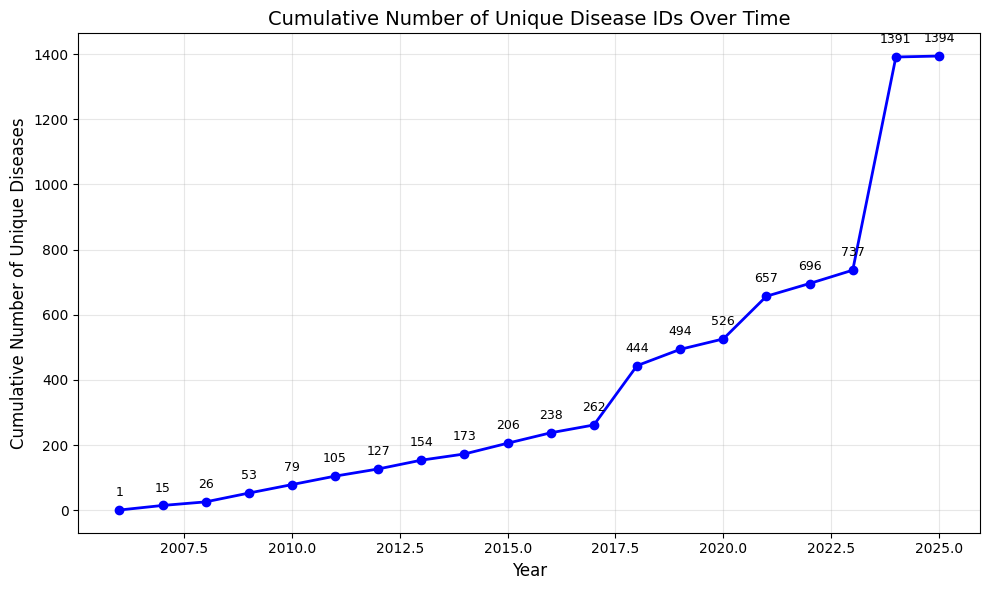

Year-wise cumulative unique disease counts:
    year  unique_diseases
0   2006                1
1   2007               15
2   2008               26
3   2009               53
4   2010               79
5   2011              105
6   2012              127
7   2013              154
8   2014              173
9   2015              206
10  2016              238
11  2017              262
12  2018              444
13  2019              494
14  2020              526
15  2021              657
16  2022              696
17  2023              737
18  2024             1391
19  2025             1394


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Get all unique years to iterate through
years_list = sorted(l2g_pandas['year'].unique())

yearly_disease_counts = []

for target_year in years_list:
    # Filter data up to the target year (cumulative)
    data_up_to_year = l2g_pandas[l2g_pandas['year'] <= target_year]
    
    # Count unique diseaseIds up to this year
    unique_diseases = data_up_to_year['diseaseId'].nunique()
    
    # Store results
    yearly_disease_counts.append({
        'year': target_year,
        'unique_diseases': unique_diseases
    })

# Convert to pandas DataFrame
yearly_disease_stats = pd.DataFrame(yearly_disease_counts)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_disease_stats['year'], yearly_disease_stats['unique_diseases'], 
         marker='o', linewidth=2, markersize=6, color='blue')

# Add labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cumulative Number of Unique Diseases', fontsize=12)
plt.title('Cumulative Number of Unique Disease IDs Over Time', fontsize=14)
plt.grid(True, alpha=0.3)

# Show values on points
for i, row in yearly_disease_stats.iterrows():
    plt.annotate(f"{row['unique_diseases']}", 
                (row['year'], row['unique_diseases']), 
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print the data
print("Year-wise cumulative unique disease counts:")
print(yearly_disease_stats)

In [20]:
diseaseIds_to_2017=list(l2g_pandas[l2g_pandas["year"]<=2017]["diseaseId"].unique())

In [21]:
l2g_pandas_2017=l2g_pandas[l2g_pandas["diseaseId"].isin(diseaseIds_to_2017)]

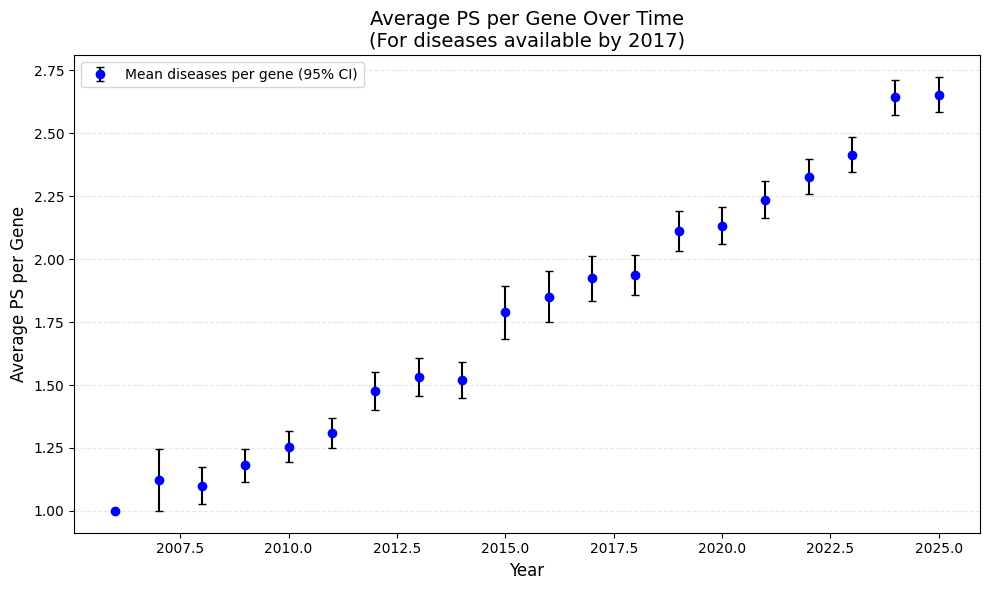

Year-wise statistics:
    year  n_genes  mean_diseases_per_gene  std_diseases   se_mean
0   2006        1                1.000000           NaN       NaN
1   2007       41                1.121951      0.399695  0.062422
2   2008      119                1.100840      0.399045  0.036580
3   2009      227                1.180617      0.513511  0.034083
4   2010      360                1.255556      0.593580  0.031284
5   2011      552                1.309783      0.720490  0.030666
6   2012      787                1.475222      1.070223  0.038149
7   2013      996                1.531124      1.231102  0.039009
8   2014     1152                1.519097      1.222999  0.036033
9   2015     1332                1.788288      1.983080  0.054336
10  2016     1525                1.851148      2.016860  0.051646
11  2017     1923                1.923557      1.985085  0.045268
12  2018     2447                1.937066      2.039502  0.041229
13  2019     2904                2.111570      2.21850

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get all unique years to iterate through
years_list = sorted(l2g_pandas_2017['year'].unique())

yearly_results = []

for target_year in years_list:
    # Filter data up to the target year
    data_up_to_year = l2g_pandas_2017[l2g_pandas_2017['year'] <= target_year]
    
    # Count number of diseaseIds per gene (for diseases available by 2017)
    diseases_per_gene = data_up_to_year.groupby('geneId')['diseaseId'].nunique()
    
    # Calculate statistics
    n = len(diseases_per_gene)
    mean_diseases = diseases_per_gene.mean()
    std_diseases = diseases_per_gene.std()
    se_mean = std_diseases / np.sqrt(n)
    
    # Store results
    yearly_results.append({
        'year': target_year,
        'n_genes': n,
        'mean_diseases_per_gene': mean_diseases,
        'std_diseases': std_diseases,
        'se_mean': se_mean
    })

# Convert to pandas DataFrame
yearly_stats_pd = pd.DataFrame(yearly_results)

# Create the plot
years = yearly_stats_pd["year"]  
mean_diseases = yearly_stats_pd["mean_diseases_per_gene"]
ci_low = yearly_stats_pd["mean_diseases_per_gene"] - 1.96 * yearly_stats_pd["se_mean"]
ci_high = yearly_stats_pd["mean_diseases_per_gene"] + 1.96 * yearly_stats_pd["se_mean"]

plt.figure(figsize=(10, 6))
plt.errorbar(years, mean_diseases, yerr=[mean_diseases - ci_low, ci_high - mean_diseases], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Mean diseases per gene (95% CI)")

# Add labels and title
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average PS per Gene", fontsize=12)
plt.title("Average PS per Gene Over Time\n(For diseases available by 2017)", fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

# Print the data
print("Year-wise statistics:")
print(yearly_stats_pd)

# Other

In [10]:
l2g_pandas

,studyLocusId,studyId,geneId,score,eQTL_coloc,pQTL_coloc,VEP,distanceTSS,maf,variantId,year,is_nfe,diseaseIds,nfe_common,non_nfe_common,rare,diseaseId
0,0005218bc3a62e3875f2ba0a0b63c349,GCST90014010,ENSG00000099337,0.846704,0,0,1,1,0.025813,19_38320104_C_G,2021,1,[EFO_0010968],1,0,0,EFO_0010968
1,00274cac95947bd00ef224652b48fc40,GCST90476299,ENSG00000184937,0.711790,0,0,0,1,0.207268,11_32406628_A_AT,2024,1,[EFO_0004309],1,0,0,EFO_0004309
2,009c65f69b7705d4c8af7a58b5ab9a26,GCST90019523,ENSG00000244067,0.761353,1,0,0,1,0.353228,6_52763753_A_G,2021,1,[EFO_0004530],1,0,0,EFO_0004530
3,00a2c80e5097f8a93c98a2a1a84416be,GCST90445994,ENSG00000176920,0.847261,1,0,0,1,0.439372,19_48703346_C_T,2024,1,[EFO_0020946],1,0,0,EFO_0020946
4,00a70f45252881a9f8c30da194b55e26,GCST90250905,ENSG00000254636,0.314682,0,0,0,1,0.115703,10_122443113_T_G,2023,1,[EFO_0009927],1,0,0,EFO_0009927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540892,ff1004aa835ec27723a5c2a41fbe1095,GCST005984,ENSG00000157152,0.646441,1,0,1,1,0.308280,3_12053630_G_A,2018,0,[OBA_0003747],0,1,0,OBA_0003747
540893,ff2274ea9823d1a9a6c8aa9c310361e8,GCST007067,ENSG00000105229,0.338166,0,0,0,1,0.027623,19_4020529_A_G,2018,1,[EFO_0004343],1,0,0,EFO_0004343
540894,ff51b67af87ae62250360a96719027ad,GCST90479668,ENSG00000120690,0.641206,1,0,0,1,0.145877,13_40904827_G_A,2024,0,[EFO_0004587],0,1,0,EFO_0004587
540895,ff5bde5a307ee23e408567cd6982c022,FINNGEN_R12_DM_RETINOPATHY_EXMORE,ENSG00000166033,0.616406,1,0,0,1,0.230150,10_122470508_A_C,2024,0,[EFO_0003770],0,1,0,EFO_0003770


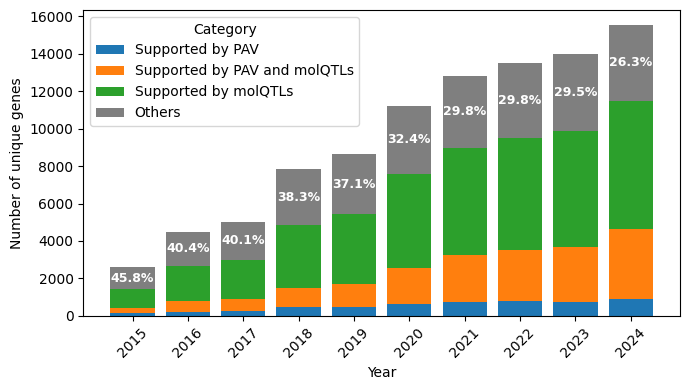

In [19]:
# ...existing code...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ensure numeric boolean flags (robust to str/float/bool)
l2g_pandas = l2g_pandas.copy()
l2g_pandas["_VEP"] = pd.to_numeric(l2g_pandas.get("VEP", 0), errors="coerce").fillna(0) >= 1
l2g_pandas["_eQTL_coloc"] = pd.to_numeric(l2g_pandas.get("eQTL_coloc", 0), errors="coerce").fillna(0) >= 1
l2g_pandas["_pQTL_coloc"] = pd.to_numeric(l2g_pandas.get("pQTL_coloc", 0), errors="coerce").fillna(0) >= 1

years = list(range(2015, 2025))
rows = []
for y in years:
    df_up = l2g_pandas[l2g_pandas["year"] <= y]
    genes_all = set(df_up["geneId"].unique())
    genes_vep = set(df_up.loc[df_up["_VEP"], "geneId"].unique())
    genes_coloc = set(df_up.loc[df_up["_eQTL_coloc"] | df_up["_pQTL_coloc"], "geneId"].unique())

    only1 = len(genes_vep - genes_coloc)              # VEP only
    overlap = len(genes_vep & genes_coloc)           # VEP & coloc
    only2 = len(genes_coloc - genes_vep)             # coloc only
    others = len(genes_all - (genes_vep | genes_coloc))  # neither

    rows.append({"year": y, "only1": only1, "overlap": overlap, "only2": only2, "others": others})

counts_df = pd.DataFrame(rows).set_index("year")

# ...existing code...
colors = {"only1": "#1f77b4", "overlap": "#ff7f0e", "only2": "#2ca02c", "others": "#7f7f7f"}

# map dataframe columns -> legend display names (order shown in the stacked bars)
col_label_map = [
    ("only1", "Supported by PAV"),
    ("overlap", "Supported by PAV and molQTLs"),
    ("only2", "Supported by molQTLs"),
    ("others", "Others"),
]

plt.figure(figsize=(7, 4))
bottom = np.zeros(len(counts_df))
totals = counts_df.sum(axis=1).values  # total genes per year (for % calc)
for col_key, display_label in col_label_map:
    vals = counts_df[col_key].values
    plt.bar(counts_df.index, vals, bottom=bottom, label=display_label, color=colors[col_key])
    # annotate the "others" segment with percentage of the yearly total
    if col_key == "others":
        for x, b, v, tot in zip(counts_df.index, bottom, vals, totals):
            if tot > 0 and v > 0:
                pct = v / tot * 100
                plt.text(x, b + v / 2, f"{pct:.1f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom = bottom + vals

plt.xticks(counts_df.index, rotation=45)
plt.xlabel("Year")
plt.ylabel("Number of unique genes")
plt.legend(title="Category")
plt.tight_layout()
plt.show()
# ...existing code...

In [12]:
import pandas as pd
import numpy as np

# Get all unique years to iterate through
years_list = sorted(l2g_pandas['year'].unique())

yearly_results = []

for target_year in years_list:
    # Filter data up to the target year
    data_up_to_year = l2g_pandas[l2g_pandas['year'] <= target_year]
    
    # Get maximum score for each gene across all years up to target year
    max_scores_per_gene = data_up_to_year.groupby(["geneId","diseaseId"])['score'].max()
    
    # Calculate statistics
    n = len(max_scores_per_gene)
    mean_score = max_scores_per_gene.mean()
    std_score = max_scores_per_gene.std()
    se_mean = std_score / np.sqrt(n)
    
    # Store results
    yearly_results.append({
        'year': target_year,
        'n': n,
        'mean_score': mean_score,
        'std_score': std_score,
        'se_mean': se_mean
    })

# Convert to pandas DataFrame
yearly_stats_pd = pd.DataFrame(yearly_results)

# Display the results
print(yearly_stats_pd)

    year       n  mean_score  std_score   se_mean
0   2006       2    0.781978   0.027724  0.019604
1   2007      51    0.646038   0.241700  0.033845
2   2008     192    0.615148   0.238535  0.017215
3   2009     506    0.616819   0.230221  0.010235
4   2010     892    0.614450   0.225360  0.007546
5   2011    1423    0.608374   0.224017  0.005939
6   2012    2163    0.606286   0.223351  0.004802
7   2013    2849    0.609326   0.221796  0.004155
8   2014    3917    0.615514   0.222182  0.003550
9   2015    5542    0.605222   0.224364  0.003014
10  2016   12875    0.609514   0.226958  0.002000
11  2017   15000    0.609477   0.226770  0.001852
12  2018   27881    0.605603   0.226344  0.001356
13  2019   35713    0.603390   0.225866  0.001195
14  2020   59751    0.607180   0.227388  0.000930
15  2021   88123    0.608907   0.228379  0.000769
16  2022  105195    0.609941   0.228516  0.000705
17  2023  122475    0.612457   0.229765  0.000657
18  2024  180933    0.608017   0.231009  0.000543


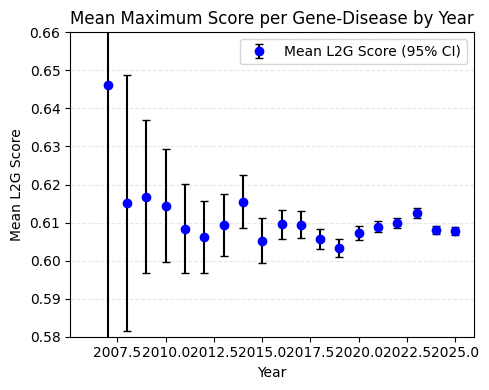

In [13]:
data_to_plot = yearly_stats_pd

import matplotlib.pyplot as plt

years = data_to_plot["year"]  
mean_scores = data_to_plot["mean_score"]
ci_low = data_to_plot["mean_score"] - 1.96 * data_to_plot["se_mean"]
ci_high = data_to_plot["mean_score"] + 1.96 * data_to_plot["se_mean"]

# Create the plot
plt.figure(figsize=(5, 4))
plt.errorbar(years, mean_scores, yerr=[mean_scores - ci_low, ci_high - mean_scores], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Mean L2G Score (95% CI)")

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Mean L2G Score")
plt.title("Mean Maximum Score per Gene-Disease by Year")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.58, 0.66)  # Assuming L2G scores are between 0 and 1

# Show the plot
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

# Get all unique years to iterate through
years_list = sorted(l2g_pandas['year'].unique())

yearly_results = []

for target_year in years_list:
    # Filter data up to the target year
    data_up_to_year = l2g_pandas[l2g_pandas['year'] <= target_year]
    
    # Get maximum score for each gene across all years up to target year
    max_scores_per_gene = data_up_to_year.groupby(["geneId","diseaseId"])['VEP'].max()
    
    # Calculate statistics
    n = len(max_scores_per_gene)
    mean_score = max_scores_per_gene.mean()
    std_score = max_scores_per_gene.std()
    se_mean = std_score / np.sqrt(n)
    
    # Store results
    yearly_results.append({
        'year': target_year,
        'n': n,
        'mean_score': mean_score,
        'std_score': std_score,
        'se_mean': se_mean
    })

# Convert to pandas DataFrame
yearly_stats_pd = pd.DataFrame(yearly_results)

# Display the results
print(yearly_stats_pd)

    year       n  mean_score  std_score   se_mean
0   2006       2    0.500000   0.707107  0.500000
1   2007      51    0.254902   0.440143  0.061632
2   2008     192    0.218750   0.414479  0.029912
3   2009     506    0.185771   0.389306  0.017307
4   2010     892    0.184978   0.388497  0.013008
5   2011    1423    0.172874   0.378271  0.010028
6   2012    2163    0.171059   0.376647  0.008099
7   2013    2849    0.170235   0.375905  0.007043
8   2014    3917    0.163390   0.369769  0.005908
9   2015    5542    0.156261   0.363136  0.004878
10  2016   12875    0.156194   0.363053  0.003200
11  2017   15000    0.158400   0.365128  0.002981
12  2018   27881    0.140131   0.347129  0.002079
13  2019   35713    0.137121   0.343980  0.001820
14  2020   59751    0.139864   0.346849  0.001419
15  2021   88123    0.143901   0.350991  0.001182
16  2022  105195    0.148923   0.356015  0.001098
17  2023  122475    0.152537   0.359542  0.001027
18  2024  180933    0.145971   0.353078  0.000830


25/09/25 22:50:10 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 949745 ms exceeds timeout 120000 ms
25/09/25 22:50:10 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/25 22:50:14 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

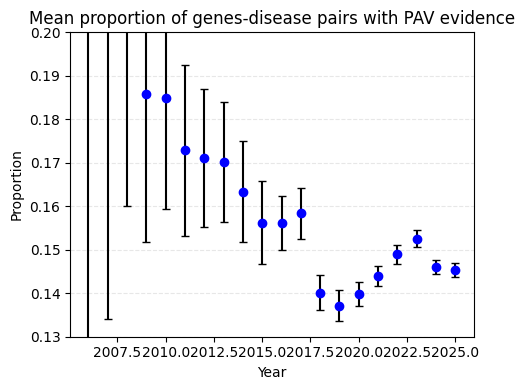

In [11]:
data_to_plot = yearly_stats_pd

import matplotlib.pyplot as plt

years = data_to_plot["year"]  
mean_scores = data_to_plot["mean_score"]
ci_low = data_to_plot["mean_score"] - 1.96 * data_to_plot["se_mean"]
ci_high = data_to_plot["mean_score"] + 1.96 * data_to_plot["se_mean"]

# Create the plot
plt.figure(figsize=(5, 4))
plt.errorbar(years, mean_scores, yerr=[mean_scores - ci_low, ci_high - mean_scores], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Mean L2G Score (95% CI)")

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.title("Mean proportion of genes-disease pairs with PAV evidence")
#plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.13, 0.2)  # Assuming L2G scores are between 0 and 1

# Show the plot
plt.tight_layout()
plt.show()

In [68]:
import pandas as pd
import numpy as np

# Get all unique years to iterate through
years_list = sorted(l2g_pandas['year'].unique())

yearly_results = []

for target_year in years_list:
    # Filter data up to the target year
    data_up_to_year = l2g_pandas[l2g_pandas['year'] <= target_year]
    
    # Get maximum score for each gene across all years up to target year
    max_scores_per_gene = data_up_to_year.groupby(["geneId","diseaseId"])['eQTL_coloc'].max()
    
    # Calculate statistics
    n = len(max_scores_per_gene)
    mean_score = max_scores_per_gene.mean()
    std_score = max_scores_per_gene.std()
    se_mean = std_score / np.sqrt(n)
    
    # Store results
    yearly_results.append({
        'year': target_year,
        'n': n,
        'mean_score': mean_score,
        'std_score': std_score,
        'se_mean': se_mean
    })

# Convert to pandas DataFrame
yearly_stats_pd = pd.DataFrame(yearly_results)

# Display the results
print(yearly_stats_pd)

    year      n  mean_score  std_score   se_mean
0   2006      1    0.000000        NaN       NaN
1   2007     46    0.456522   0.503610  0.074253
2   2008    131    0.458015   0.500147  0.043698
3   2009    268    0.440299   0.497352  0.030381
4   2010    452    0.451327   0.498177  0.023432
5   2011    723    0.439834   0.496710  0.018473
6   2012   1161    0.434109   0.495853  0.014552
7   2013   1525    0.443934   0.497010  0.012727
8   2014   1750    0.428571   0.495013  0.011833
9   2015   2382    0.416037   0.493003  0.010101
10  2016   2823    0.409139   0.491762  0.009255
11  2017   3699    0.420654   0.493731  0.008118
12  2018   5777    0.418210   0.493308  0.006490
13  2019   8040    0.407463   0.491393  0.005480
14  2020   9738    0.406244   0.491156  0.004977
15  2021  13560    0.408555   0.491585  0.004222
16  2022  16275    0.403379   0.490591  0.003846
17  2023  18878    0.405234   0.490950  0.003573
18  2024  35535    0.404503   0.490802  0.002604
19  2025  36858    0

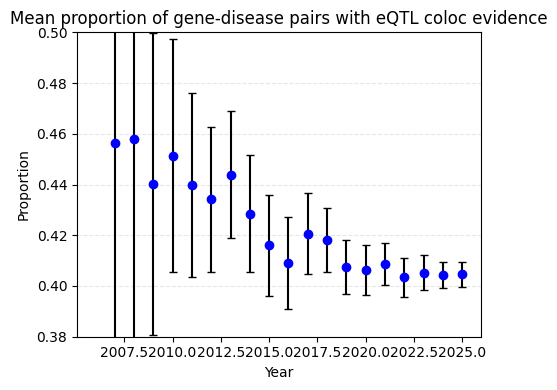

In [69]:
data_to_plot = yearly_stats_pd

import matplotlib.pyplot as plt

years = data_to_plot["year"]  
mean_scores = data_to_plot["mean_score"]
ci_low = data_to_plot["mean_score"] - 1.96 * data_to_plot["se_mean"]
ci_high = data_to_plot["mean_score"] + 1.96 * data_to_plot["se_mean"]

# Create the plot
plt.figure(figsize=(5, 4))
plt.errorbar(years, mean_scores, yerr=[mean_scores - ci_low, ci_high - mean_scores], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Mean eQTL Coloc Score (95% CI)")

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.title("Mean proportion of gene-disease pairs with eQTL coloc evidence")
#plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.38, 0.5)  # Assuming L2G scores are between 0 and 1

# Show the plot
plt.tight_layout()
plt.show()

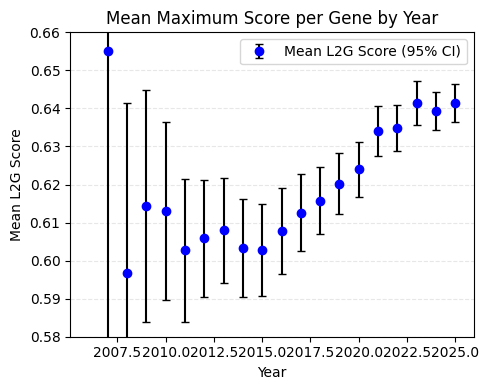

In [70]:
import pandas as pd
import numpy as np

# Get all unique years to iterate through
years_list = sorted(l2g_pandas['year'].unique())

yearly_results = []

for target_year in years_list:
    # Filter data up to the target year
    data_up_to_year = l2g_pandas[l2g_pandas['year'] <= target_year]
    
    # Get maximum score for each gene across all years up to target year
    max_scores_per_gene = data_up_to_year.groupby(["geneId"])['score'].max()
    
    # Calculate statistics
    n = len(max_scores_per_gene)
    mean_score = max_scores_per_gene.mean()
    std_score = max_scores_per_gene.std()
    se_mean = std_score / np.sqrt(n)
    
    # Store results
    yearly_results.append({
        'year': target_year,
        'n': n,
        'mean_score': mean_score,
        'std_score': std_score,
        'se_mean': se_mean
    })

# Convert to pandas DataFrame
yearly_stats_pd = pd.DataFrame(yearly_results)

data_to_plot = yearly_stats_pd

import matplotlib.pyplot as plt

years = data_to_plot["year"]  
mean_scores = data_to_plot["mean_score"]
ci_low = data_to_plot["mean_score"] - 1.96 * data_to_plot["se_mean"]
ci_high = data_to_plot["mean_score"] + 1.96 * data_to_plot["se_mean"]

# Create the plot
plt.figure(figsize=(5, 4))
plt.errorbar(years, mean_scores, yerr=[mean_scores - ci_low, ci_high - mean_scores], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Mean L2G Score (95% CI)")

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Mean L2G Score")
plt.title("Mean Maximum Score per Gene by Year")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.58, 0.66)  # Assuming L2G scores are between 0 and 1

# Show the plot
plt.tight_layout()
plt.show()

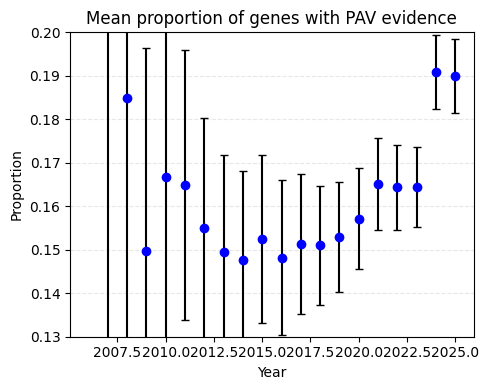

In [71]:
import pandas as pd
import numpy as np

# Get all unique years to iterate through
years_list = sorted(l2g_pandas['year'].unique())

yearly_results = []

for target_year in years_list:
    # Filter data up to the target year
    data_up_to_year = l2g_pandas[l2g_pandas['year'] <= target_year]
    
    # Get maximum score for each gene across all years up to target year
    max_scores_per_gene = data_up_to_year.groupby(["geneId"])['VEP'].max()
    
    # Calculate statistics
    n = len(max_scores_per_gene)
    mean_score = max_scores_per_gene.mean()
    std_score = max_scores_per_gene.std()
    se_mean = std_score / np.sqrt(n)
    
    # Store results
    yearly_results.append({
        'year': target_year,
        'n': n,
        'mean_score': mean_score,
        'std_score': std_score,
        'se_mean': se_mean
    })

# Convert to pandas DataFrame
yearly_stats_pd = pd.DataFrame(yearly_results)

data_to_plot = yearly_stats_pd

import matplotlib.pyplot as plt

years = data_to_plot["year"]  
mean_scores = data_to_plot["mean_score"]
ci_low = data_to_plot["mean_score"] - 1.96 * data_to_plot["se_mean"]
ci_high = data_to_plot["mean_score"] + 1.96 * data_to_plot["se_mean"]

# Create the plot
plt.figure(figsize=(5, 4))
plt.errorbar(years, mean_scores, yerr=[mean_scores - ci_low, ci_high - mean_scores], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Mean L2G Score (95% CI)")

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.title("Mean proportion of genes with PAV evidence")
#plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.13, 0.2)  # Assuming L2G scores are between 0 and 1

# Show the plot
plt.tight_layout()
plt.show()

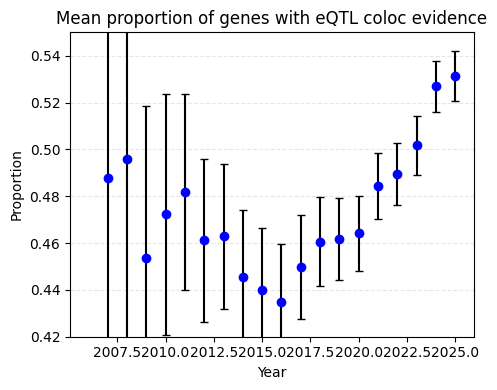

In [73]:
import pandas as pd
import numpy as np

# Get all unique years to iterate through
years_list = sorted(l2g_pandas['year'].unique())

yearly_results = []

for target_year in years_list:
    # Filter data up to the target year
    data_up_to_year = l2g_pandas[l2g_pandas['year'] <= target_year]
    
    # Get maximum score for each gene across all years up to target year
    max_scores_per_gene = data_up_to_year.groupby(["geneId"])['eQTL_coloc'].max()
    
    # Calculate statistics
    n = len(max_scores_per_gene)
    mean_score = max_scores_per_gene.mean()
    std_score = max_scores_per_gene.std()
    se_mean = std_score / np.sqrt(n)
    
    # Store results
    yearly_results.append({
        'year': target_year,
        'n': n,
        'mean_score': mean_score,
        'std_score': std_score,
        'se_mean': se_mean
    })

# Convert to pandas DataFrame
yearly_stats_pd = pd.DataFrame(yearly_results)

data_to_plot = yearly_stats_pd

import matplotlib.pyplot as plt

years = data_to_plot["year"]  
mean_scores = data_to_plot["mean_score"]
ci_low = data_to_plot["mean_score"] - 1.96 * data_to_plot["se_mean"]
ci_high = data_to_plot["mean_score"] + 1.96 * data_to_plot["se_mean"]

# Create the plot
plt.figure(figsize=(5, 4))
plt.errorbar(years, mean_scores, yerr=[mean_scores - ci_low, ci_high - mean_scores], 
             fmt='o', color='blue', ecolor='black', capsize=3, 
             label="Mean eQTL Coloc Score (95% CI)")

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Proportion")
plt.title("Mean proportion of genes with eQTL coloc evidence")
#plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.42, 0.55)  # Assuming L2G scores are between 0 and 1

# Show the plot
plt.tight_layout()
plt.show()

# TMP


In [75]:
x=session.spark.read.parquet("gs://ot-team/irene/cautionary_targets/cautionary_targets.parquet")

In [76]:
x.count()

4886

In [77]:
x.show()


+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+
|       targetId|pharmacogene|liable_target|withdrawn_drug|essential_gene|mouse_ko_mortality|dd_related|cancer_driver_gene|trial_safety_concern|drug_target|non_oncology_drug_target|oncology_drug_target|
+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+
|        CACNA1E|        NULL|         NULL|          NULL|          NULL|              NULL|         1|              NULL|                NULL|       NULL|                    NULL|                NULL|
|ENSG00000083454|        NULL|            1|          NULL|          NULL|              NULL|      NULL|              NULL|                NULL|       NULL|                    NULL|       

In [118]:
target=session.spark.read.parquet("gs://open-targets-pipeline-runs/il/25.09-testrun-1/output/target")

In [119]:
#target=session.spark.read.parquet("gs://open-targets-data-releases/25.06/output/target")
target=target.filter(f.col("biotype")=="protein_coding").cache()
target.count()

25/09/18 16:57:53 WARN CacheManager: Asked to cache already cached data.


20130

In [120]:
target=target.withColumnRenamed("id","targetId")

In [121]:
x=x.join(target.select("targetId"),on="targetId",how="inner")

In [126]:
# Get all columns except targetId
value_columns = [col for col in x.columns if col != "targetId"]

# Melt with all value columns
x_long = x.melt(
    ids=["targetId"],  # identifier columns to keep
    values=value_columns,  # explicitly specify all other columns
    variableColumnName="variable",
    valueColumnName="value"
).filter(f.col("value")==1)

x_long.show(1)

+---------------+------------+-----+
|       targetId|    variable|value|
+---------------+------------+-----+
|ENSG00000001084|pharmacogene|    1|
+---------------+------------+-----+
only showing top 1 row



In [127]:
x_long.count()

3843

In [128]:
x_long.groupBy("variable").count().show()

+--------------------+-----+
|            variable|count|
+--------------------+-----+
|         drug_target|   20|
|oncology_drug_target|    6|
|  cancer_driver_gene|  368|
|non_oncology_drug...|   16|
|      withdrawn_drug|  166|
|      essential_gene| 1489|
|       liable_target|  214|
|        pharmacogene|  540|
|trial_safety_concern|    2|
|  mouse_ko_mortality| 1022|
+--------------------+-----+



In [129]:
x_long.groupBy("value").count().show()

+-----+-----+
|value|count|
+-----+-----+
|    1| 3843|
+-----+-----+



In [130]:
x_long=x_long.filter(~f.col("variable").isin(["drug_target","oncology_drug_target","non_oncology_drug_target"]))

In [131]:
x_long.groupBy("variable").count().show()

+--------------------+-----+
|            variable|count|
+--------------------+-----+
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|      essential_gene| 1489|
|       liable_target|  214|
|        pharmacogene|  540|
|trial_safety_concern|    2|
|  mouse_ko_mortality| 1022|
+--------------------+-----+



25/09/18 19:35:11 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1011346 ms exceeds timeout 120000 ms
25/09/18 19:35:11 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/18 19:35:14 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

In [109]:
x_long.select("targetId").distinct().count()

3320

In [112]:
# Count occurrences of each targetId
target_counts = x_long.groupBy("targetId").count()

# Filter to keep only targetIds that appear 2 or more times
targets_with_multiple = target_counts.filter(f.col("count") >= 2)

# Get the count of such targets
print(f"Number of targets with 2+ cautionary flags: {targets_with_multiple.count()}")

# If you want to filter the original x_long to keep only these targets
x_long_filtered = x_long.join(
    targets_with_multiple.select("targetId"), 
    on="targetId", 
    how="inner"
)

print(f"Filtered x_long count: {x_long_filtered.count()}")

Number of targets with 2+ cautionary flags: 386
Filtered x_long count: 867


In [114]:
(x_long
 .filter(f.col("variable").isin("withdrawn_drug","pharmacogene","trial_safety_concern","liable_target"))
 .select("targetId")
 .distinct()
 .count()
)

787